In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
a = [-4,3,5,6,2]
print(np.maximum(a, 0))

[0 3 5 6 2]


3175


Text(0.5, 0, 'Frequency (GHz)')

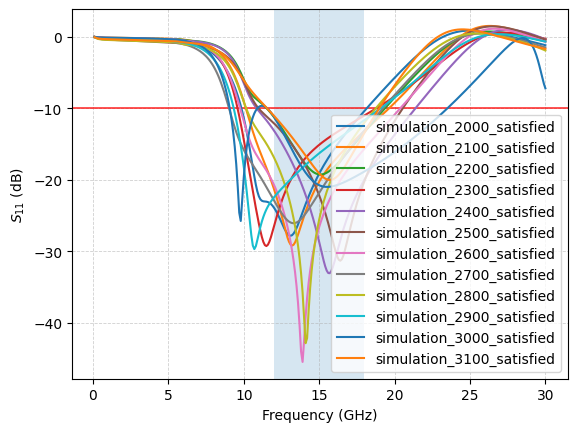

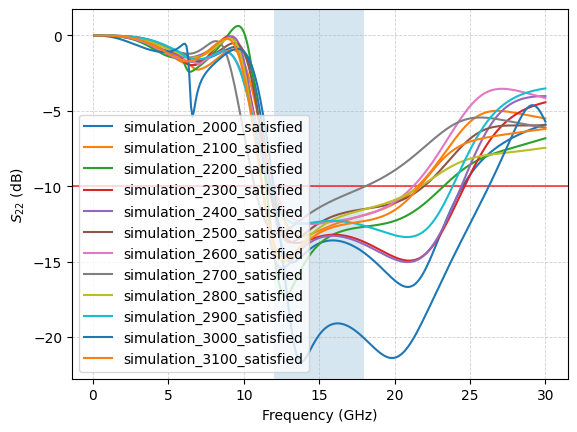

In [3]:
import pandas as pd

df = pd.read_csv("/home/jychung/python/target_spec/reward_mean_calc2/S11.csv")
s22 = pd.read_csv("/home/jychung/python/target_spec/reward_mean_calc2/S22.csv")

print(s22.shape[1])

#s11
plt.figure()

plt.axvspan(12, 18, alpha=0.18)
plt.axhline(y=-10, linestyle="-", linewidth=1.2,alpha=0.8, color='red')
plt.grid(True, which="both", linestyle='--', linewidth=0.6, alpha=0.6)

idx_target_freq = np.where((df["freq"] >= 12e9) & (df["freq"] <= 18e9))[0]

for i in range(2000, df.shape[1]):
    if(i%100 == 0):
        if (np.maximum(np.max(df[f"{i}"][idx_target_freq]), -10) <= -10):
            plt.plot(df["freq"]/(1e9), df[f"{i}"], label=f'simulation_{i}_satisfied')
        else:
            plt.plot(df["freq"]/(1e9), df[f"{i}"], label=f'simulation_{i}_not_satisfied')


# plt.plot(df["freq"], df["10"], label=f'episode_10')
plt.legend(loc='lower right', fontsize=10)
plt.ylabel(r'$S_{11}$ (dB)')
plt.xlabel('Frequency (GHz)')

#s22
plt.figure()

plt.axvspan(12, 18, alpha=0.18)
plt.axhline(y=-10, linestyle="-", linewidth=1.2,alpha=0.8, color='red')
plt.grid(True, which="both", linestyle='--', linewidth=0.6, alpha=0.6)

idx_target_freq = np.where((s22["freq"] >= 12e9) & (s22["freq"] <= 18e9))[0]

for i in range(2000, s22.shape[1]):
    if(i%100 == 0):
        if (np.maximum(np.max(s22[f"{i}"][idx_target_freq]), -10) <= -10):
            plt.plot(s22["freq"]/(1e9), s22[f"{i}"], label=f'simulation_{i}_satisfied')
        else:
            plt.plot(s22["freq"]/(1e9), s22[f"{i}"], label=f'simulation_{i}_not_satisfied')

# plt.plot(df["freq"], df["10"], label=f'episode_10')
plt.legend(loc='lower left', fontsize=10)
plt.ylabel(r'$S_{22}$ (dB)')
plt.xlabel('Frequency (GHz)')


In [6]:
data = np.load("/home/jychung/python/final_params.npz")

print(data.files)
print(data["general_TL"])

['general_TL', 'bias_TL', 'ELC']
[2.67500010e-04 8.81485501e-05 1.83640792e-04 2.38647698e-04
 2.19376595e-04 1.44955252e-04 1.00176367e-04 1.24609062e-04
 2.64487412e-04 2.14048379e-04 1.91234084e-04]


Text(0.5, 0, 'Frequency (GHz)')

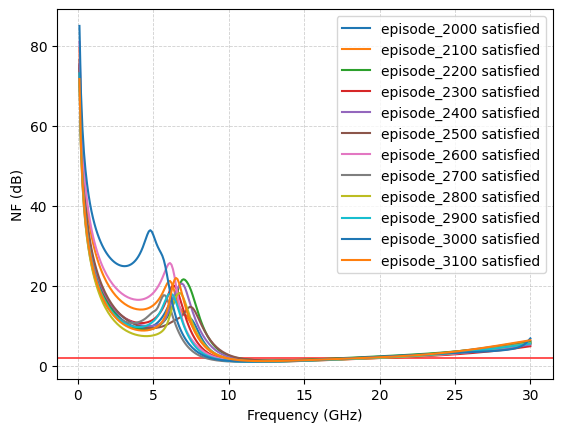

In [4]:

df = pd.read_csv("/home/jychung/python/target_spec/reward_mean_calc2/NF.csv")

plt.figure()

plt.axvspan(12e9, 18e9, alpha=0.18)
plt.axhline(y=2, linestyle="-", linewidth=1.2,alpha=0.8, color='red')
plt.grid(True, which="both", linestyle='--', linewidth=0.6, alpha=0.6)


for i in range(2000, df.shape[1]):
    if(i%100 == 0):
        if (np.maximum(np.max(df[f"{i}"][idx_target_freq]), 2) <= 2):
            plt.plot(df["freq"]/(1e9), df[f"{i}"], label=f'episode_{i} satisfied')
        else:
            plt.plot(df["freq"]/(1e9), df[f"{i}"], label=f'episode_{i} not satisfied')


# plt.plot(df["freq"], df["10"], label=f'episode_10')
plt.legend(loc='upper right', fontsize=10)
plt.ylabel(r'NF (dB)')
plt.xlabel('Frequency (GHz)')